# AgroPlus - Benchmark Modelos Tabulares (EVA L2, mascara agricola)

Notebook de contraste de **3 modelos tabulares** para clasificacion de cultivos en Cundinamarca.

## Protocolo
- **Datos de entrenamiento**: vista minable filtrada a `fuente == "eva_municipal"` con **mascara agricola** aplicada (estrategia LLP-Co). Se excluyen `noapto_proxy` y `monitoreo` (UPRA) del entrenamiento.
- **Etiqueta**: `argmax(prob_*)` (soft labels EVA) sobre las 18 clases L2 — nunca el campo `cultivo`.
- **Mascara agricola** (`ndvi_mean_temporal`, `ndvi_sigma_temporal`):
  - Excluye suelo desnudo / agua / urbano (`mean < 0.15`)
  - Excluye bosque denso primario (`mean > 0.80 AND sigma < 0.06`)
  - Excluye bosque secundario / pastura permanente (`mean > 0.55 AND sigma < 0.04`)
- **Split**: 80/20 por municipio (sin fuga espacial), seed=42.
- **UPRA**: queda **fuera** del entrenamiento. Solo se usa como ground truth de campo para validacion independiente (Recall Papa).
- **Features**: 29 features identicas al checkpoint LLP-Co.
- **Modelos**: Random Forest (500 arboles), XGBoost (300 est.), Regresion Logistica.
- **Metricas**: Accuracy, F1, Precision, Recall, ROC-AUC (macro OvR).
- **Mapas departamentales**: prediccion binaria por cultivo sobre toda Cundinamarca (con mascara agricola), 18 cultivos.


In [61]:
# ============================================================
# SECCION 0 - Imports y Constantes
# ============================================================
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# --- Rutas ---
ROOT       = Path('..')
DATA_PATH  = ROOT / 'vista_minable' / 'vista_minable_full.parquet'
CKPT_PATH  = Path('checkpoints') / 'l2_llp_co.pt'
SEED       = 42

# --- Clases L2 (18 clases, mismas que LLP-Co) ---
CLASES_L2 = [
    'Cana_Panelera', 'Cafe', 'Maiz', 'Platano', 'Mango', 'Frijol',
    'Cacao', 'Arveja', 'Palma', 'Banano', 'Citricos', 'Mora',
    'Zanahoria', 'Tomate_Arbol', 'Yuca', 'Habichuela', 'Hortalizas', 'Papa'
]
PROB_COLS  = [f'prob_{c}' for c in CLASES_L2]
N_CLASSES  = len(CLASES_L2)  # 18

# --- Features (29, identicas al checkpoint) ---
FEATURE_COLS = [
    'pendiente', 'twi', 'sg_phh2o', 'sg_soc', 'sg_cec', 'sg_bdod',
    'sg_clay', 'sg_sand', 'sg_silt', 'igac_fertilidad', 'igac_ph',
    'igac_potasio', 'igac_vocacion', 'piso_termico', 'aspecto_sin',
    'aspecto_cos', 'ndvi_sigma_temporal', 'ndvi_mean_temporal',
    'temperatura_media', 'humedad_media', 'chirps_acum',
    's2_gndvi_max', 's2_msavi_max', 's2_bsi_max', 's2_bsi_std',
    'amplitud_termica', 'anomalia_precip', 'ndvi_integral', 'indice_aridez'
]
assert len(FEATURE_COLS) == 29, f'Se esperaban 29 features, hay {len(FEATURE_COLS)}'

# --- Paleta de colores para 18 clases ---
cmap20 = plt.cm.get_cmap('tab20', 20)
COLOR_MAP = {cls: cmap20(i) for i, cls in enumerate(CLASES_L2)}


def expand_proba(raw_proba, classes_seen, n_total=N_CLASSES):
    """Expande predict_proba(n, K_seen) a (n, n_total) con zeros en clases ausentes."""
    if raw_proba.shape[1] == n_total:
        return raw_proba
    full = np.zeros((len(raw_proba), n_total), dtype=np.float32)
    for i, ci in enumerate(classes_seen):
        full[:, ci] = raw_proba[:, i]
    return full


print(f'N_CLASSES : {N_CLASSES}')
print(f'N_FEATURES: {len(FEATURE_COLS)}')
print('Setup OK')


N_CLASSES : 18
N_FEATURES: 29
Setup OK


## 1. Carga de Datos y Ficha Tecnica


In [62]:
# ============================================================
# SECCION 1 - Carga y Ficha Tecnica
# ============================================================
print('Cargando vista_minable_full.parquet ...')
df_raw = pd.read_parquet(DATA_PATH)
print(f'  Shape total: {df_raw.shape}')

# --- Dataset de entrenamiento: SOLO EVA municipal ---
# UPRA queda FUERA del entrenamiento para evitar fuga de features.
# La etiqueta proviene siempre de prob_* (argmax), nunca del campo cultivo.
df_all = df_raw[df_raw['fuente'] == 'eva_municipal'].copy()

# --- UPRA reservado: ground truth de campo para Recall Papa ---
df_upra = df_raw[df_raw['fuente'] == 'monitoreo'].copy()

n_eva  = len(df_all)
n_upra = len(df_upra)

print()
print('FICHA TECNICA (antes de mascara agricola)')
print('=' * 55)
print(f'  EVA municipal (train pool)      : {n_eva:>10,} filas')
print(f'  UPRA monitoreo (validacion)     : {n_upra:>10,} filas')
print(f'  Municipios EVA                  : {df_all["cod_mun"].nunique():>10}')
print(f'  Municipios UPRA                 : {df_upra["cod_mun"].nunique():>10}')
print(f'  Features                        : {len(FEATURE_COLS):>10}')
print(f'  Clases L2 (prob_*)              : {N_CLASSES:>10}')
print()
print('Nulos por feature (EVA):')
nulos = df_all[FEATURE_COLS].isnull().sum()
print(nulos[nulos > 0].to_string() if (nulos > 0).any() else '  Sin nulos')


Cargando vista_minable_full.parquet ...
  Shape total: (4165215, 77)

FICHA TECNICA (antes de mascara agricola)
  EVA municipal (train pool)      :  2,998,317 filas
  UPRA monitoreo (validacion)     :    566,029 filas
  Municipios EVA                  :        111
  Municipios UPRA                 :         91
  Features                        :         29
  Clases L2 (prob_*)              :         18

Nulos por feature (EVA):
sg_clay                 23475
sg_sand                 23475
sg_silt                 23475
piso_termico           119766
ndvi_sigma_temporal        45
ndvi_mean_temporal         45
s2_gndvi_max            18774
s2_msavi_max            18773
s2_bsi_max              18779


## 1.1 Mascara Agricola (estrategia LLP-Co)

Se excluyen pixeles claramente no-agricolas usando `ndvi_mean_temporal` y `ndvi_sigma_temporal`:
- **F1**: `ndvi_mean < 0.15` → suelo desnudo / agua / urbano sin vegetacion.
- **F2**: `ndvi_mean > 0.80 AND ndvi_sigma < 0.06` → bosque denso primario.
- **F3**: `ndvi_mean > 0.55 AND ndvi_sigma < 0.04` → bosque secundario / pastura permanente.

La misma funcion se reutiliza al predecir sobre los 4.16M pixeles de Cundinamarca (Seccion 8.2 / 8.3).


In [63]:
# ============================================================
# SECCION 1.1 - Mascara Agricola
# ============================================================
SIGMA_COL = 'ndvi_sigma_temporal'
MEAN_COL  = 'ndvi_mean_temporal'


def mascara_agricola(df):
    """
    Devuelve una mascara booleana sobre df que conserva solo
    pixeles agricolas potenciales (excluye suelo, bosque primario y
    pastura permanente segun NDVI temporal). Replica el filtro del
    notebook CRISP_DM_AgroPlus_LLP_Co_V1.
    """
    sigma = df[SIGMA_COL]
    mean  = df[MEAN_COL]
    f1 = ~(mean < 0.15)
    f2 = ~((mean > 0.80) & (sigma.fillna(1) < 0.06))
    f3 = ~((mean > 0.55) & (sigma.fillna(1) < 0.04))
    return (f1 & f2 & f3).values


# --- Aplicar al pool de entrenamiento (EVA municipal) ---
n0 = len(df_all)
mask_train_ag = mascara_agricola(df_all)
df_all = df_all.iloc[mask_train_ag].reset_index(drop=True)
n_excl_train = n0 - len(df_all)

# --- Aplicar a UPRA tambien (consistente con el espacio agricola) ---
n0u = len(df_upra)
mask_upra_ag = mascara_agricola(df_upra)
df_upra = df_upra.iloc[mask_upra_ag].reset_index(drop=True)
n_excl_upra = n0u - len(df_upra)

print('Mascara agricola - EVA (entrenamiento):')
print(f'  Inicial   : {n0:>10,}')
print(f'  Excluidos : {n_excl_train:>10,}  ({100*n_excl_train/n0:.1f}%)')
print(f'  Quedan    : {len(df_all):>10,}  ({100*len(df_all)/n0:.1f}%)')
print()
print('Mascara agricola - UPRA (validacion):')
print(f'  Inicial   : {n0u:>10,}')
print(f'  Excluidos : {n_excl_upra:>10,}  ({100*n_excl_upra/n0u:.1f}%)')
print(f'  Quedan    : {len(df_upra):>10,}  ({100*len(df_upra)/n0u:.1f}%)')
print()
print(f'  Municipios EVA (post-mascara) : {df_all["cod_mun"].nunique()}')
print(f'  Municipios UPRA (post-mascara): {df_upra["cod_mun"].nunique()}')


Mascara agricola - EVA (entrenamiento):
  Inicial   :  2,998,317
  Excluidos :    666,079  (22.2%)
  Quedan    :  2,332,238  (77.8%)

Mascara agricola - UPRA (validacion):
  Inicial   :    566,029
  Excluidos :     85,807  (15.2%)
  Quedan    :    480,222  (84.8%)

  Municipios EVA (post-mascara) : 111
  Municipios UPRA (post-mascara): 91


## 2. Preparacion de Etiquetas (Soft -> Hard)

Cada pixel (EVA y UPRA) recibe la clase del cultivo con mayor proporcion en `prob_*` via `argmax`. La columna `cultivo` no interviene en el etiquetado.


In [64]:
# ============================================================
# SECCION 2 - Soft Labels -> Hard Labels (EVA municipal)
# ============================================================
# df_all contiene solo pixeles EVA municipal con mascara agricola aplicada.
# El campo cultivo NO se usa para etiquetar.

missing = [c for c in PROB_COLS if c not in df_all.columns]
assert not missing, f'Columnas faltantes: {missing}'

# Filas sin ningun prob_* valido (todo NaN): no se pueden etiquetar
W_raw = df_all[PROB_COLS].values.astype(np.float32)
valid_mask = ~np.isnan(W_raw).all(axis=1)
n_sin_prob = (~valid_mask).sum()
if n_sin_prob > 0:
    print(f'Advertencia: {n_sin_prob:,} pixeles sin prob_* validos seran excluidos.')

# Imputar NaN con 0 antes del argmax (filas con prob_* parciales)
W = np.where(np.isnan(W_raw), 0.0, W_raw)

y_idx = W.argmax(axis=1)        # (n,) int 0-17
y_idx = y_idx[valid_mask]

y_nombres = np.array(CLASES_L2)[y_idx]
print('Distribucion de clases tras argmax(prob_*) [EVA + mascara agricola]:')
unique, counts = np.unique(y_nombres, return_counts=True)
for c, n in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f'  {c:<20}: {n:>10,}  ({100*n/len(y_idx):.1f}%)')
print(f'  TOTAL                : {len(y_idx):>10,}')

# Arrays finales (solo EVA, solo agricolas, solo con prob_* validos)
X_all      = df_all[FEATURE_COLS].values.astype(np.float32)[valid_mask]
y_all      = y_idx
mun_all    = df_all['cod_mun'].values[valid_mask]
coords_all = df_all[['x', 'y', 'cod_mun']].values[valid_mask]
print(f'\nX_all: {X_all.shape}   y_all: {y_all.shape}')


Distribucion de clases tras argmax(prob_*) [EVA + mascara agricola]:
  Papa                :  1,686,701  (72.3%)
  Hortalizas          :    190,044  (8.1%)
  Maiz                :    110,632  (4.7%)
  Cafe                :    108,210  (4.6%)
  Frijol              :     76,602  (3.3%)
  Palma               :     51,869  (2.2%)
  Mora                :     28,201  (1.2%)
  Cana_Panelera       :     19,476  (0.8%)
  Yuca                :     10,752  (0.5%)
  Habichuela          :     10,197  (0.4%)
  Citricos            :      9,778  (0.4%)
  Banano              :      8,415  (0.4%)
  Mango               :      6,561  (0.3%)
  Cacao               :      6,530  (0.3%)
  Platano             :      4,621  (0.2%)
  Tomate_Arbol        :      1,869  (0.1%)
  Arveja              :      1,780  (0.1%)
  TOTAL                :  2,332,238

X_all: (2332238, 29)   y_all: (2332238,)


## 3. Split Train / Test por Municipio

Split 80/20 por `cod_mun` para evitar fuga espacial, identico al protocolo de LLP-Co.


In [65]:
# ============================================================
# SECCION 3 - Split Train/Test por Municipio (solo EVA)
# ============================================================
# Split sobre municipios EVA. UPRA queda fuera del entrenamiento.
# Para Recall Papa se usan los pixeles UPRA cuyo municipio cayo en test.

munis_all = np.unique(mun_all)
mun_train, mun_test = train_test_split(
    munis_all, test_size=0.20, random_state=SEED
)
mun_train = set(mun_train)
mun_test  = set(mun_test)

mask_tr = np.isin(mun_all, list(mun_train))
mask_te = np.isin(mun_all, list(mun_test))

X_train, y_train = X_all[mask_tr], y_all[mask_tr]
X_test,  y_test  = X_all[mask_te], y_all[mask_te]
coords_test      = coords_all[mask_te]

# --- UPRA: solo evaluacion. Pixeles UPRA en municipios test (ground truth campo) ---
mun_col_upra = df_upra['cod_mun'].values
mask_upra_te = np.isin(mun_col_upra, list(mun_test))
df_upra_te   = df_upra[mask_upra_te].copy()
X_upra_te    = df_upra_te[FEATURE_COLS].values.astype(np.float32)
coords_upra  = df_upra_te[['x', 'y']].values
y_upra_true  = df_upra_te['cultivo'].values   # Papa / Otros_cultivos (hard label UPRA)

print(f'Municipios train (EVA) : {len(mun_train)}')
print(f'Municipios test  (EVA) : {len(mun_test)}')
print(f'X_train                : {X_train.shape}  (solo EVA, municipios train)')
print(f'X_test                 : {X_test.shape}   (solo EVA, municipios test, hold-out)')
print(f'UPRA test pixels       : {len(df_upra_te):,} en {df_upra_te["cod_mun"].nunique()} municipios')
print(f'                         (NUNCA vistos durante entrenamiento -> ground truth limpio)')
print()
print('Distribucion de clases en test (argmax prob_*):')
for ci, cls in enumerate(CLASES_L2):
    n = (y_test == ci).sum()
    if n > 0:
        print(f'  {cls:<20}: {n:>8,}')


Municipios train (EVA) : 88
Municipios test  (EVA) : 23
X_train                : (1684509, 29)  (solo EVA, municipios train)
X_test                 : (647729, 29)   (solo EVA, municipios test, hold-out)
UPRA test pixels       : 134,443 en 19 municipios
                         (NUNCA vistos durante entrenamiento -> ground truth limpio)

Distribucion de clases en test (argmax prob_*):
  Cana_Panelera       :    3,987
  Cafe                :   15,870
  Maiz                :   24,730
  Mango               :       48
  Frijol              :   27,709
  Palma               :   51,869
  Citricos            :      105
  Mora                :   28,201
  Hortalizas          :   19,019
  Papa                :  476,191


## 4. Preprocesamiento

Imputacion de nulos con mediana y escalado estandar. El scaler se ajusta SOLO en train.


In [66]:
# ============================================================
# SECCION 4 - Preprocesamiento
# ============================================================

# Imputacion de nulos
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)
X_upra_imp  = imputer.transform(X_upra_te)

# Escalado estandar
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp).astype(np.float32)
X_test_sc  = scaler.transform(X_test_imp).astype(np.float32)
X_upra_sc  = scaler.transform(X_upra_imp).astype(np.float32)

print(f'X_train_sc : {X_train_sc.shape}')
print(f'X_test_sc  : {X_test_sc.shape}')
print(f'X_upra_sc  : {X_upra_sc.shape}')
print('Preprocesamiento OK')


X_train_sc : (1684509, 29)
X_test_sc  : (647729, 29)
X_upra_sc  : (134443, 29)
Preprocesamiento OK


## 5. Entrenamiento de Modelos Tabulares

### 5.1 Random Forest


In [67]:
# ============================================================
# SECCION 5.1 - Random Forest
# ============================================================
print('Entrenando Random Forest (n_estimators=500, class_weight=balanced)...')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED,
    max_depth=None,
    min_samples_leaf=5,
)
rf.fit(X_train_sc, y_train)
t_rf = time.time() - t0

y_pred_rf      = rf.predict(X_test_sc)
y_proba_rf     = expand_proba(rf.predict_proba(X_test_sc), rf.classes_)
y_pred_upra_rf = rf.predict(X_upra_sc)

print(f'  Clases vistas en train: {len(rf.classes_)} / {N_CLASSES}')
print(f'  Tiempo de entrenamiento: {t_rf:.1f}s')
print(f'  Accuracy en test: {accuracy_score(y_test, y_pred_rf):.4f}')


Entrenando Random Forest (n_estimators=500, class_weight=balanced)...
  Clases vistas en train: 15 / 18
  Tiempo de entrenamiento: 335.9s
  Accuracy en test: 0.7136


### 5.2 XGBoost (GPU)

XGBoost se entrena en **GPU** (`device='cuda'`, `tree_method='hist'`). RF y LR permanecen en CPU porque sklearn no tiene aceleracion GPU nativa en Windows (RAPIDS/cuML solo soporta WSL2).

In [68]:
# ============================================================
# SECCION 5.2 - XGBoost (GPU)
# ============================================================
# XGBoost 3.x requiere labels consecutivos 0..K-1.
# Usamos un LabelEncoder interno para reasignar y luego revertir.
# Entrenamiento e inferencia en GPU (device='cuda').

# Verificar GPU disponible
import subprocess
try:
    res = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=5)
    GPU_OK = (res.returncode == 0)
except Exception:
    GPU_OK = False
XGB_DEVICE = 'cuda' if GPU_OK else 'cpu'
print(f'XGBoost device: {XGB_DEVICE}')

print(f'Entrenando XGBoost (n_estimators=300, tree_method=hist, device={XGB_DEVICE})...')
t0 = time.time()

le_xgb = LabelEncoder()
y_train_xgb = le_xgb.fit_transform(y_train)   # 0..K_present-1
sw_xgb = compute_sample_weight('balanced', y_train_xgb)

xgb = XGBClassifier(
    n_estimators=300,
    tree_method='hist',
    device=XGB_DEVICE,
    objective='multi:softprob',
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=SEED,
    learning_rate=0.1,
    max_depth=6,
    verbosity=0,
)
xgb.fit(X_train_sc, y_train_xgb, sample_weight=sw_xgb)
t_xgb = time.time() - t0

# Predicciones: revertir a indices originales (0-17)
y_pred_xgb      = le_xgb.inverse_transform(xgb.predict(X_test_sc))
y_pred_upra_xgb = le_xgb.inverse_transform(xgb.predict(X_upra_sc))

# Probabilidades: expandir a (n, 18) usando clases originales
y_proba_xgb = expand_proba(xgb.predict_proba(X_test_sc), le_xgb.classes_)

print(f'  Clases vistas en train: {len(le_xgb.classes_)} / {N_CLASSES}')
print(f'  Tiempo de entrenamiento ({XGB_DEVICE}): {t_xgb:.1f}s')
print(f'  Accuracy en test: {accuracy_score(y_test, y_pred_xgb):.4f}')


XGBoost device: cuda
Entrenando XGBoost (n_estimators=300, tree_method=hist, device=cuda)...
  Clases vistas en train: 15 / 18
  Tiempo de entrenamiento (cuda): 46.5s
  Accuracy en test: 0.5978


### 5.3 Regresion Logistica

> **Nota**: LR se entrena sobre una muestra estratificada de 400K filas para reducir tiempo de convergencia. El espacio de clases y features es identico.


In [69]:
# ============================================================
# SECCION 5.3 - Regresion Logistica
# ============================================================
# Subsample estratificado para viabilidad de convergencia
MAX_LR = 400_000
if len(X_train_sc) > MAX_LR:
    rng = np.random.default_rng(SEED)
    idx_lr = rng.choice(len(X_train_sc), size=MAX_LR, replace=False)
    X_lr, y_lr = X_train_sc[idx_lr], y_train[idx_lr]
    print(f'Muestra para LR: {MAX_LR:,} de {len(X_train_sc):,} filas')
else:
    X_lr, y_lr = X_train_sc, y_train

print('Entrenando Regresion Logistica (lbfgs, max_iter=2000)...')
t0 = time.time()

lr_model = LogisticRegression(
    max_iter=2000,
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    n_jobs=-1,
    random_state=SEED,
)
lr_model.fit(X_lr, y_lr)
t_lr = time.time() - t0

y_pred_lr      = lr_model.predict(X_test_sc)
y_proba_lr     = expand_proba(lr_model.predict_proba(X_test_sc), lr_model.classes_)
y_pred_upra_lr = lr_model.predict(X_upra_sc)

print(f'  Clases vistas en train: {len(lr_model.classes_)} / {N_CLASSES}')
print(f'  Tiempo de entrenamiento: {t_lr:.1f}s')
print(f'  Accuracy en test: {accuracy_score(y_test, y_pred_lr):.4f}')


Muestra para LR: 400,000 de 1,684,509 filas
Entrenando Regresion Logistica (lbfgs, max_iter=2000)...
  Clases vistas en train: 15 / 18
  Tiempo de entrenamiento: 33.7s
  Accuracy en test: 0.4891


## 7. Metricas Comparativas


In [70]:
# ============================================================
# SECCION 7 - Tabla y Grafico de Metricas
# ============================================================

def compute_metrics(y_true, y_pred, y_proba, nombre):
    # ROC-AUC: clases presentes en y_true, renormalizadas a sumar 1
    present = sorted(np.unique(y_true).tolist())
    try:
        proba_sub = y_proba[:, present].astype(np.float64)
        row_sums  = proba_sub.sum(axis=1, keepdims=True)
        row_sums  = np.where(row_sums == 0, 1.0, row_sums)
        proba_sub = proba_sub / row_sums
        auc = roc_auc_score(
            y_true, proba_sub, multi_class='ovr', average='macro', labels=present
        )
    except Exception:
        auc = float('nan')
    return {
        'Modelo'    : nombre,
        'Accuracy'  : accuracy_score(y_true, y_pred),
        'F1'        : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Precision' : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall'    : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'ROC-AUC'   : auc,
    }

resultados = [
    compute_metrics(y_test, y_pred_rf,  y_proba_rf,  'Random Forest'),
    compute_metrics(y_test, y_pred_xgb, y_proba_xgb, 'XGBoost'),
    compute_metrics(y_test, y_pred_lr,  y_proba_lr,  'Log. Regresion'),
]

df_metrics = pd.DataFrame(resultados).set_index('Modelo')
print('=== TABLA COMPARATIVA DE METRICAS (test hold-out EVA por municipio) ===')
print(df_metrics.to_string())

df_tiempos = pd.DataFrame([
    {'Modelo': 'Random Forest',  'Tiempo (s)': round(t_rf,  1), 'Tipo': 'train (full EVA train)'},
    {'Modelo': 'XGBoost',        'Tiempo (s)': round(t_xgb, 1), 'Tipo': f'train GPU ({XGB_DEVICE})'},
    {'Modelo': 'Log. Regresion', 'Tiempo (s)': round(t_lr,  1), 'Tipo': 'train (subsample 400K EVA)'},
]).set_index('Modelo')
print()
print('=== TIEMPOS DE ENTRENAMIENTO ===')
print(df_tiempos.to_string())


=== TABLA COMPARATIVA DE METRICAS (test hold-out EVA por municipio) ===
                Accuracy     F1  Precision  Recall  ROC-AUC
Modelo                                                     
Random Forest     0.7136 0.6975     0.6881  0.7136   0.7989
XGBoost           0.5978 0.6348     0.6953  0.5978   0.7697
Log. Regresion    0.4891 0.5750     0.7230  0.4891   0.7184

=== TIEMPOS DE ENTRENAMIENTO ===
                Tiempo (s)                        Tipo
Modelo                                                
Random Forest     335.9000      train (full EVA train)
XGBoost            46.5000            train GPU (cuda)
Log. Regresion     33.7000  train (subsample 400K EVA)


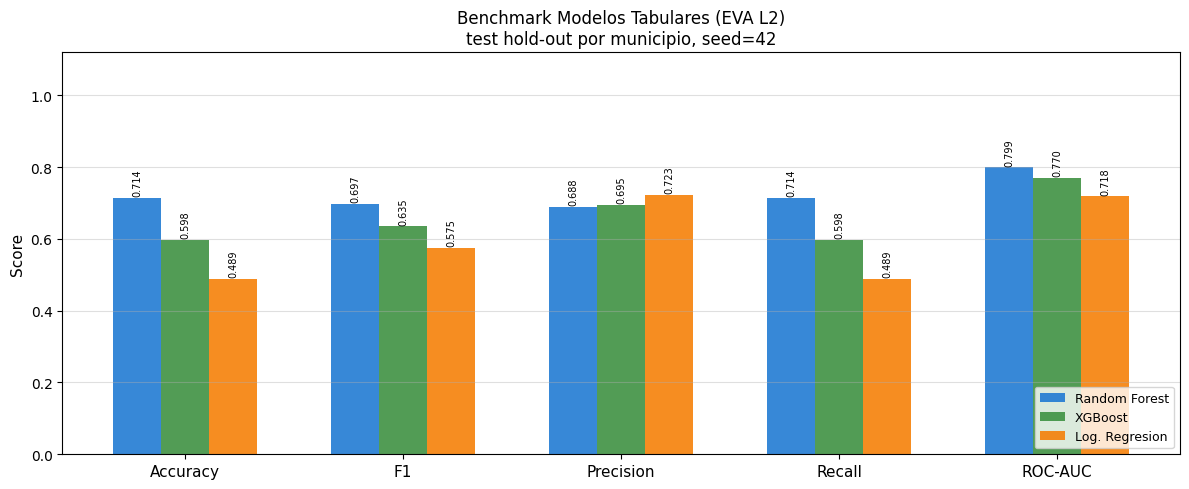

Grafico guardado en benchmark_metricas.png


In [71]:
# ============================================================
# GRAFICO - Grouped bar chart (3 modelos tabulares)
# ============================================================
METRICAS = ['Accuracy', 'F1', 'Precision', 'Recall', 'ROC-AUC']
MODELOS  = df_metrics.index.tolist()
COLORES  = ['#1976D2', '#388E3C', '#F57C00']  # RF, XGB, LR

x       = np.arange(len(METRICAS))
width   = 0.22
offsets = np.array([-1, 0, 1]) * width

fig, ax = plt.subplots(figsize=(12, 5))

for modelo, color, offset in zip(MODELOS, COLORES, offsets):
    vals = [df_metrics.loc[modelo, m] for m in METRICAS]
    bars = ax.bar(x + offset, vals, width=width, label=modelo, color=color, alpha=0.87)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(METRICAS, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(
    'Benchmark Modelos Tabulares (EVA L2)\n'
    'test hold-out por municipio, seed=42',
    fontsize=12
)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('benchmark_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado en benchmark_metricas.png')


## 8. Mapa Papa - UPRA (ground truth) vs Prediccion del modelo

Para cada modelo se genera una figura de 2 paneles cubriendo toda Cundinamarca:
- **Izquierda**: fraccion de pixeles Papa por municipio segun observacion UPRA de campo (ground truth).
- **Derecha**: probabilidad Papa predicha por el modelo sobre el area agricola del departamento.

### Estrategia de rendimiento
Para evitar el costo de `scatter` con ~4M puntos, los datos se **rasterizan** a una grilla 2D de 50 m y se renderizan con `imshow`. Esto reduce el tiempo de render de minutos a segundos por mapa.

Cargando vista minable completa via pyarrow...
  Pixeles totales: 4,165,215  (0.3s)
Construyendo matriz de features...
  X_full: (4165215, 29)  (1.4s)
Aplicando mascara Cundinamarca (cod_mun valido)...
  Pixeles dentro de Cundinamarca: 3,650,285  (87.6%)
Aplicando mascara agricola...
  Pixeles agricolas dentro de Cundinamarca: 2,883,734  (69.2%)  (0.0s)
  Grilla raster: 1557 x 1305 celdas a 150 m  (factor area 9.0x sobre 50 m)
Construyendo raster UPRA (fraccion Papa por municipio agregada por celda)...
  UPRA pixeles: 480,135 | celdas con dato UPRA: 84,875  (0.2s)
Preprocesando features agricolas (imputer + scaler)...
  X_agr: (2883734, 29)  (0.9s)
Inferencia: Random Forest (CPU)...
  RF  : 41.7s
Inferencia: XGBoost (GPU)...
  XGB : 3.9s
Inferencia: Reg. Logistica (CPU)...
  LR  : 0.4s

Renderizando mapas...


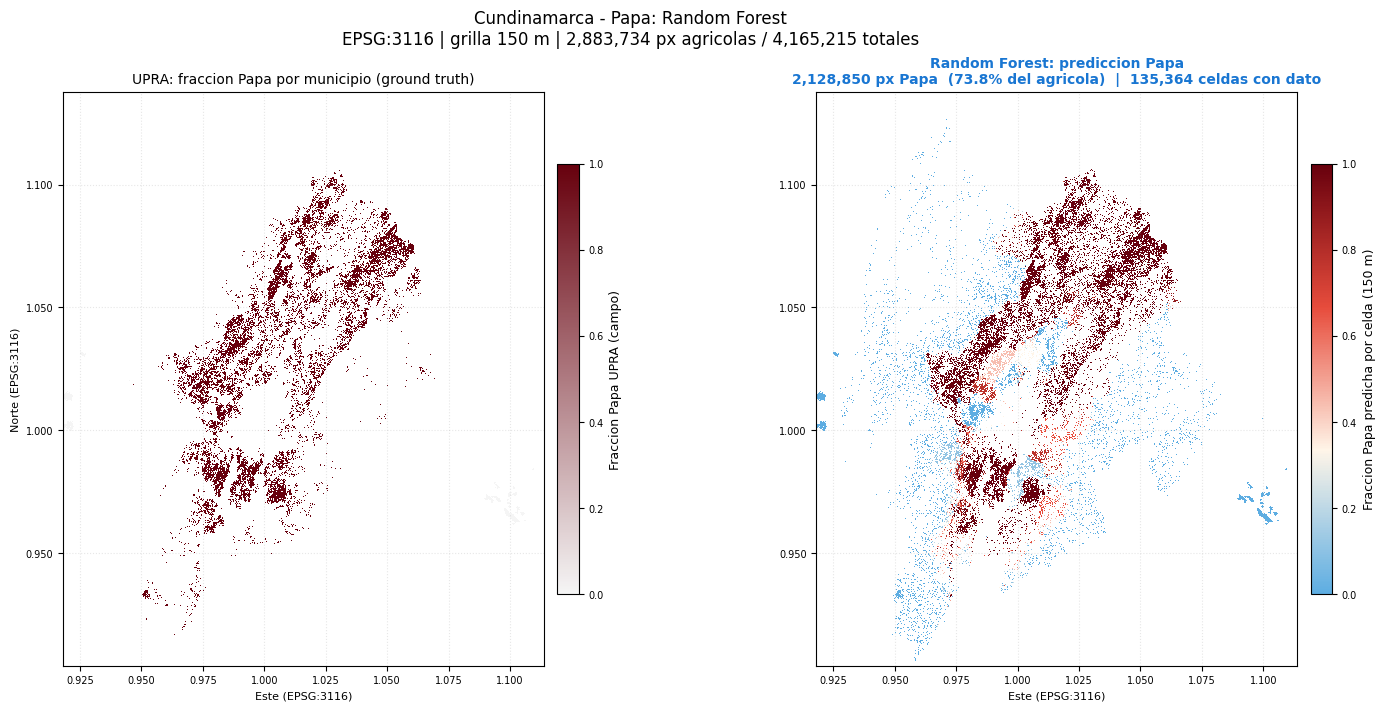

  Random Forest: 1.7s -> mapa_papa_random_forest.png


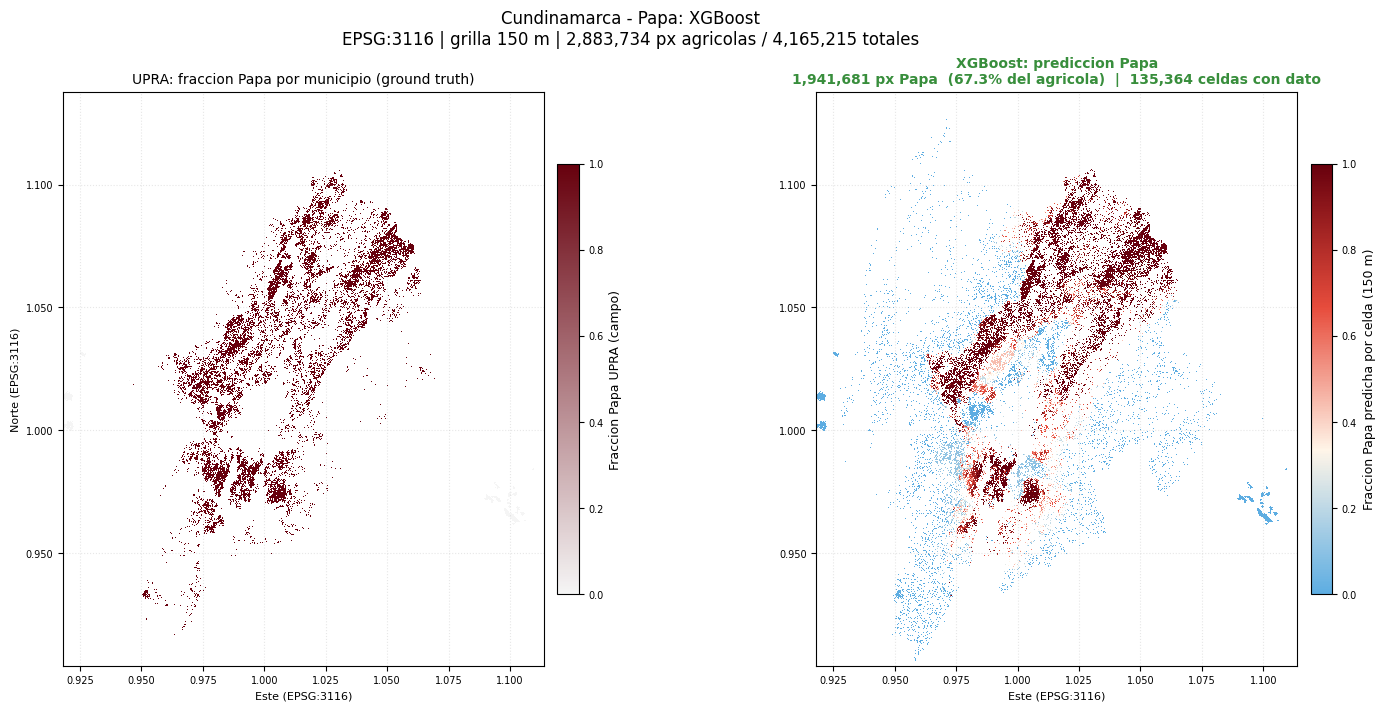

  XGBoost: 1.7s -> mapa_papa_xgboost.png


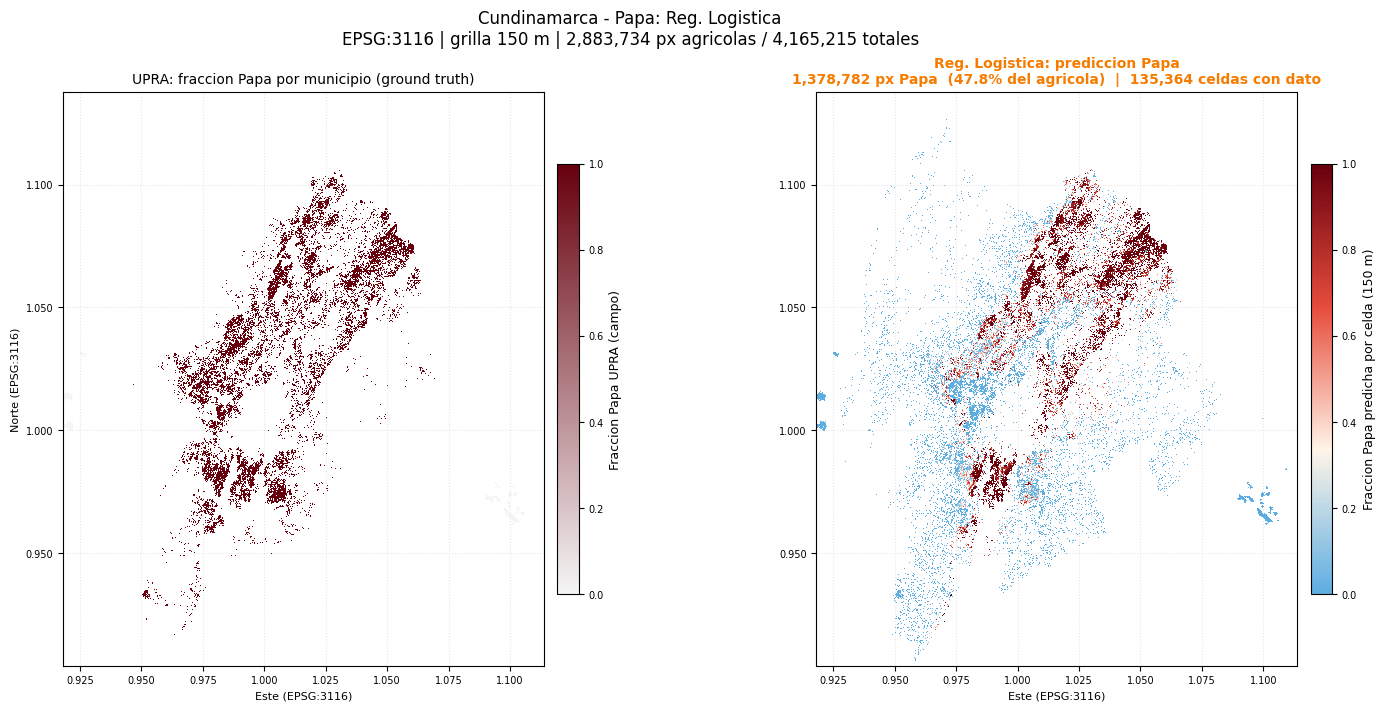

  Reg. Logistica: 1.7s -> mapa_papa_reg_logistica.png

Mapas Papa completados.


In [91]:
# ============================================================
# SECCION 8 - Mapas Papa: UPRA vs Prediccion
# - Vista minable es un muestreo estratificado (~4.16M px de ~10M cells)
# - Agregamos a grilla mas gruesa: cada celda promedia varios pixeles
#   muestreados, asi el raster se ve denso (mas datos por celda)
# - Hard labels al nivel pixel; la agregacion por celda da una densidad 0..1
# ============================================================
import pyarrow.parquet as pq
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

IDX_PAPA = CLASES_L2.index('Papa')

# Resolucion de la grilla raster. Mayor que 50m -> mas muestras por celda
# (mejor densidad visual). Tipicos: 100m (4x), 150m (9x), 200m (16x area por celda).
RES = 150.0


def _first_col(table, name):
    """Devuelve la primera columna con el nombre dado (el parquet tiene duplicados)."""
    for i, f in enumerate(table.schema):
        if f.name == name:
            return table.column(i)
    raise KeyError(f'Columna {name} no encontrada en el parquet')


def raster_mean_por_celda(ny, nx, gy_idx, gx_idx, values):
    """
    Raster (ny, nx) donde cada celda contiene la media de los valores
    de los pixeles muestreados que cayeron en ella. Celdas sin muestras = NaN.
    Implementacion vectorizada con np.bincount.
    """
    flat = gy_idx.astype(np.int64) * nx + gx_idx.astype(np.int64)
    n_cells = ny * nx
    sums   = np.bincount(flat, weights=values.astype(np.float64), minlength=n_cells)
    counts = np.bincount(flat, minlength=n_cells).astype(np.float64)
    with np.errstate(invalid='ignore', divide='ignore'):
        mean = np.where(counts > 0, sums / counts, np.nan).astype(np.float32)
    return mean.reshape(ny, nx)


# --- Lectura via pyarrow ---
print('Cargando vista minable completa via pyarrow...')
t0 = time.time()
COLS_NEEDED = ['x', 'y', 'fuente', 'cultivo', 'cod_mun',
               SIGMA_COL, MEAN_COL] + FEATURE_COLS
COLS_NEEDED = list(dict.fromkeys(COLS_NEEDED))
table = pq.read_table(str(DATA_PATH), columns=COLS_NEEDED)
n_total = table.num_rows
print(f'  Pixeles totales: {n_total:,}  ({time.time()-t0:.1f}s)')

x_all     = _first_col(table, 'x').to_numpy().astype(np.float64)
y_all     = _first_col(table, 'y').to_numpy().astype(np.float64)
fuente_a  = _first_col(table, 'fuente').to_numpy(zero_copy_only=False)
cultivo_a = _first_col(table, 'cultivo').to_numpy(zero_copy_only=False)
cod_mun_a = _first_col(table, 'cod_mun').to_numpy()
sigma_a   = _first_col(table, SIGMA_COL).to_numpy(zero_copy_only=False).astype(np.float32)
mean_a    = _first_col(table, MEAN_COL).to_numpy(zero_copy_only=False).astype(np.float32)

print('Construyendo matriz de features...')
t0 = time.time()
X_full = np.empty((n_total, len(FEATURE_COLS)), dtype=np.float32)
for j, col in enumerate(FEATURE_COLS):
    X_full[:, j] = _first_col(table, col).to_numpy(zero_copy_only=False).astype(np.float32)
del table
print(f'  X_full: {X_full.shape}  ({time.time()-t0:.1f}s)')

# --- Mascara Cundinamarca: solo pixeles con cod_mun asignado ---
# El parquet cubre el bounding-box de Cundinamarca, pero el bbox incluye
# zonas de departamentos vecinos. Filtramos por cod_mun valido (no nulo > 0).
print('Aplicando mascara Cundinamarca (cod_mun valido)...')
if cod_mun_a.dtype.kind == 'f':
    mask_cund = ~np.isnan(cod_mun_a)
else:
    mask_cund = (cod_mun_a > 0)
n_cund = int(mask_cund.sum())
print(f'  Pixeles dentro de Cundinamarca: {n_cund:,}  ({100*n_cund/n_total:.1f}%)')

# --- Mascara agricola (inline numpy) ---
print('Aplicando mascara agricola...')
t0 = time.time()
sigma_filled = np.where(np.isnan(sigma_a), 1.0, sigma_a)
f1 = ~(mean_a < 0.15)
f2 = ~((mean_a > 0.80) & (sigma_filled < 0.06))
f3 = ~((mean_a > 0.55) & (sigma_filled < 0.04))
# Mascara final: agricola Y dentro de Cundinamarca
mask_ag = f1 & f2 & f3 & mask_cund
n_agr   = int(mask_ag.sum())
print(f'  Pixeles agricolas dentro de Cundinamarca: {n_agr:,}  ({100*n_agr/n_total:.1f}%)  ({time.time()-t0:.1f}s)')

# --- Grilla 2D (resolucion RES, EPSG:3116) ---
x_min, x_max = float(x_all.min()), float(x_all.max())
y_min, y_max = float(y_all.min()), float(y_all.max())
nx = int(round((x_max - x_min) / RES)) + 1
ny = int(round((y_max - y_min) / RES)) + 1
print(f'  Grilla raster: {ny} x {nx} celdas a {RES:.0f} m  (factor area {(RES/50)**2:.1f}x sobre 50 m)')

gx = np.round((x_all - x_min) / RES).astype(np.int32)
gy = np.round((y_all - y_min) / RES).astype(np.int32)
np.clip(gx, 0, nx - 1, out=gx)
np.clip(gy, 0, ny - 1, out=gy)

# --- Raster UPRA: fraccion Papa por municipio (cada pixel UPRA aporta su frac) ---
print('Construyendo raster UPRA (fraccion Papa por municipio agregada por celda)...')
t0 = time.time()
mask_upra = (fuente_a == 'monitoreo') & mask_ag
upra_idx  = np.where(mask_upra)[0]
mun_upra  = cod_mun_a[upra_idx]
es_papa   = (cultivo_a[upra_idx] == 'Papa').astype(np.float32)

unique_muns_u, inv_u = np.unique(mun_upra, return_inverse=True)
sums_u   = np.bincount(inv_u, weights=es_papa)
counts_u = np.bincount(inv_u).astype(np.float32)
frac_per_mun_u = sums_u / counts_u
frac_px_upra   = frac_per_mun_u[inv_u].astype(np.float32)

raster_upra = raster_mean_por_celda(ny, nx, gy[upra_idx], gx[upra_idx], frac_px_upra)
print(f'  UPRA pixeles: {len(upra_idx):,} | celdas con dato UPRA: '
      f'{int(np.isfinite(raster_upra).sum()):,}  ({time.time()-t0:.1f}s)')

# --- Preprocesar features de pixeles agricolas ---
print('Preprocesando features agricolas (imputer + scaler)...')
t0 = time.time()
agr_idx = np.where(mask_ag)[0]
X_agr   = scaler.transform(imputer.transform(X_full[agr_idx])).astype(np.float32)
del X_full
print(f'  X_agr: {X_agr.shape}  ({time.time()-t0:.1f}s)')

# --- Inferencia HARD por modelo (clase 0..17 por pixel muestreado) ---
modelos_pred = []

print('Inferencia: Random Forest (CPU)...')
t0 = time.time()
pred_rf = rf.predict(X_agr)
print(f'  RF  : {time.time()-t0:.1f}s')
modelos_pred.append(('Random Forest', pred_rf, '#1976D2'))

print('Inferencia: XGBoost (GPU)...')
t0 = time.time()
pred_xgb = le_xgb.inverse_transform(xgb.predict(X_agr))
print(f'  XGB : {time.time()-t0:.1f}s')
modelos_pred.append(('XGBoost', pred_xgb, '#388E3C'))

print('Inferencia: Reg. Logistica (CPU)...')
t0 = time.time()
pred_lr = lr_model.predict(X_agr)
print(f'  LR  : {time.time()-t0:.1f}s')
modelos_pred.append(('Reg. Logistica', pred_lr, '#F57C00'))

# --- Colormaps ---
# UPRA: gradiente rojo continuo (fraccion 0..1)
cmap_red = LinearSegmentedColormap.from_list('rojo_papa', ['#f5f5f5', '#67000d'])
cmap_red.set_bad('#ffffff', alpha=0.0)

# Prediccion: gradiente azul (0% Papa) -> rojo oscuro (100% Papa por celda)
cmap_pred = LinearSegmentedColormap.from_list(
    'azul_rojo', ['#5DADE2', '#FFF5E8', '#E74C3C', '#67000D']
)
cmap_pred.set_bad('#ffffff', alpha=0.0)

extent = [x_min - RES/2, x_max + RES/2, y_min - RES/2, y_max + RES/2]

print()
print('Renderizando mapas...')
for nombre, pred_idx, color_modelo in modelos_pred:
    t0 = time.time()
    pred_papa_bin = (pred_idx == IDX_PAPA).astype(np.float32)
    n_papa = int(pred_papa_bin.sum())

    # Cada celda = fraccion de pixeles muestreados que cayeron alli que el
    # modelo etiqueto como Papa (etiquetas duras a nivel pixel, agregacion por celda)
    raster_pred = raster_mean_por_celda(
        ny, nx, gy[agr_idx], gx[agr_idx], pred_papa_bin
    )
    n_cells_filled = int(np.isfinite(raster_pred).sum())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)
    fig.suptitle(
        f'Cundinamarca - Papa: {nombre}\n'
        f'EPSG:3116 | grilla {RES:.0f} m | {n_agr:,} px agricolas / {n_total:,} totales',
        fontsize=12
    )

    # Izquierda: UPRA fraccion (ground truth)
    im1 = ax1.imshow(raster_upra, origin='lower', extent=extent,
                     cmap=cmap_red, vmin=0, vmax=1, interpolation='nearest')
    cb1 = plt.colorbar(im1, ax=ax1, shrink=0.75, pad=0.02)
    cb1.set_label('Fraccion Papa UPRA (campo)', fontsize=9)
    cb1.ax.tick_params(labelsize=7)
    ax1.set_title('UPRA: fraccion Papa por municipio (ground truth)', fontsize=10)
    ax1.set_aspect('equal')
    ax1.set_xlabel('Este (EPSG:3116)', fontsize=8)
    ax1.set_ylabel('Norte (EPSG:3116)', fontsize=8)
    ax1.tick_params(labelsize=7)
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.3f}'))
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1e6:.3f}'))
    ax1.grid(True, alpha=0.3, linestyle=':')

    # Derecha: fraccion de pixeles predichos como Papa por celda (hard labels agregadas)
    im2 = ax2.imshow(raster_pred, origin='lower', extent=extent,
                     cmap=cmap_pred, vmin=0, vmax=1, interpolation='nearest')
    cb2 = plt.colorbar(im2, ax=ax2, shrink=0.75, pad=0.02)
    cb2.set_label(f'Fraccion Papa predicha por celda ({RES:.0f} m)', fontsize=9)
    cb2.ax.tick_params(labelsize=7)
    ax2.set_title(
        f'{nombre}: prediccion Papa\n'
        f'{n_papa:,} px Papa  ({100*n_papa/n_agr:.1f}% del agricola)  |  '
        f'{n_cells_filled:,} celdas con dato',
        fontsize=10, color=color_modelo, fontweight='bold'
    )
    ax2.set_aspect('equal')
    ax2.set_xlabel('Este (EPSG:3116)', fontsize=8)
    ax2.tick_params(labelsize=7)
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.3f}'))
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1e6:.3f}'))
    ax2.grid(True, alpha=0.3, linestyle=':')

    fname = f'mapa_papa_{nombre.lower().replace(" ","_").replace(".","")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  {nombre}: {time.time()-t0:.1f}s -> {fname}')

print()
print('Mapas Papa completados.')


## 9. Metricas Papa sobre TODA el area agricola (UPRA presence-only)

Para cada pixel agricola de Cundinamarca (~3.5M), se contrasta la prediccion binaria del modelo
contra la presencia de UPRA = Papa en ese pixel:

- **Ground truth Papa** = `(fuente == 'monitoreo') AND (cultivo == 'Papa')` (UPRA marco Papa en ese pixel)
- **Ground truth no-Papa** = cualquier otro pixel agricola (EVA o UPRA `Otros_cultivos`)

Matriz de confusion:
| | UPRA marca Papa | UPRA no marca Papa |
|---|---|---|
| **Modelo: Papa** | TP | FP |
| **Modelo: no-Papa** | FN | TN |

### Sesgos a tener en cuenta
- **Recall confiable**: si UPRA marco Papa, sabemos que es Papa. Si el modelo no lo predice ahi -> FN real.
- **Precision sesgada a la baja**: si el modelo predice Papa en zonas NO monitoreadas por UPRA (que en realidad podrian ser Papa), cuenta como FP. Es un limite inferior de la Precision real.
- **Accuracy dominada por TN**: ~88% trivial al predecir "todo no-Papa". Poco discriminante.
- **F1**: balance util pero pesimista por la Precision sesgada baja.


Area agricola: 2,883,734 pixeles
  UPRA = Papa (positivos)   :    425,680  (14.76%)
  UPRA no marca Papa (neg)  :  2,458,054  (85.24%)
    de los cuales:
      EVA (sin monitoreo UPRA)        :  2,332,238
      UPRA = Otros_cultivos           :     54,455

Baseline "todo no-Papa" Accuracy = 0.8524  (referencia trivial)

=== METRICAS PAPA sobre TODA el area agricola (UPRA presence-only) ===
                Pred_Papa_total      TP      FN       FP       TN  Accuracy  Precision  Recall     F1
Modelo                                                                                               
Random Forest           2128850  372248   53432  1756602   701452    0.3723     0.1749  0.8745 0.2914
XGBoost                 1941681  344706   80974  1596975   861079    0.4181     0.1775  0.8098 0.2912
Reg. Logistica          1378782  252540  173140  1126242  1331812    0.5494     0.1832  0.5933 0.2799

Descomposicion FP por fuente del pixel:
  Modelo               FP_total    FP_en_EVA   FP_en_UPR

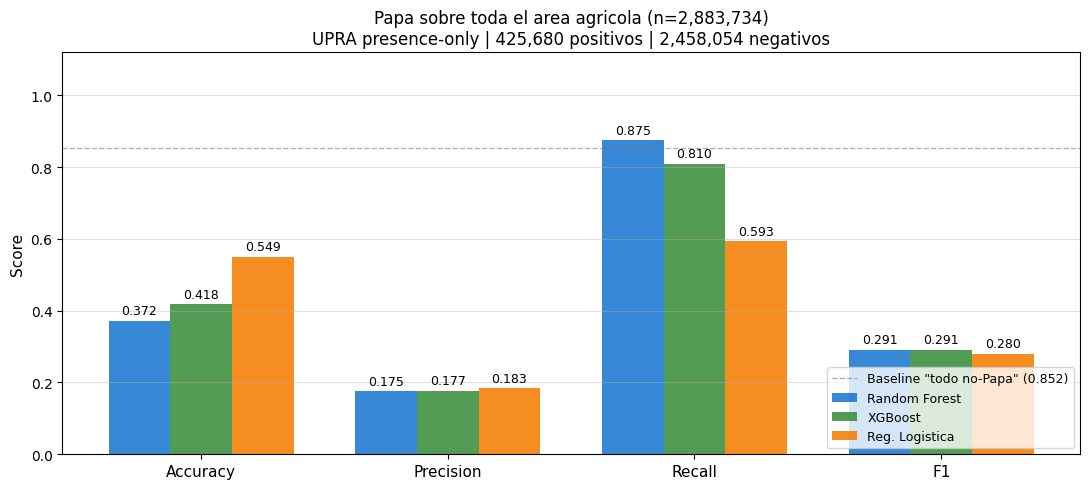

Grafico guardado en metricas_papa_global.png


In [92]:
# ============================================================
# SECCION 9 - Metricas Papa sobre TODA el area agricola
# Ground truth: UPRA presence-only (solo cuenta donde UPRA = Papa)
# Reusa pred_rf, pred_xgb, pred_lr (sobre agr_idx) y arrays fuente_a, cultivo_a
# ============================================================

# --- Ground truth binaria sobre todo el area agricola ---
fuente_agr  = fuente_a[agr_idx]
cultivo_agr = cultivo_a[agr_idx]

# Positivo = UPRA marco Papa en ese pixel (es la unica evidencia confiable)
gt_papa_global = (fuente_agr == 'monitoreo') & (cultivo_agr == 'Papa')

n_total_agr  = len(agr_idx)
n_pos_global = int(gt_papa_global.sum())
n_neg_global = n_total_agr - n_pos_global
prevalencia  = n_pos_global / n_total_agr

print(f'Area agricola: {n_total_agr:,} pixeles')
print(f'  UPRA = Papa (positivos)   : {n_pos_global:>10,}  ({100*prevalencia:.2f}%)')
print(f'  UPRA no marca Papa (neg)  : {n_neg_global:>10,}  ({100*(1-prevalencia):.2f}%)')
print(f'    de los cuales:')
n_eva_in_neg  = int((fuente_agr[~gt_papa_global] == 'eva_municipal').sum())
n_upra_otros  = int(((fuente_agr == 'monitoreo') & (cultivo_agr != 'Papa')).sum())
print(f'      EVA (sin monitoreo UPRA)        : {n_eva_in_neg:>10,}')
print(f'      UPRA = Otros_cultivos           : {n_upra_otros:>10,}')
print()
print(f'Baseline "todo no-Papa" Accuracy = {1-prevalencia:.4f}  (referencia trivial)')
print()


def metricas_global_papa(pred_idx, nombre):
    pred_papa = (pred_idx == IDX_PAPA)
    tp = int((pred_papa &  gt_papa_global).sum())
    fn = int((~pred_papa &  gt_papa_global).sum())
    fp = int((pred_papa & ~gt_papa_global).sum())
    tn = int((~pred_papa & ~gt_papa_global).sum())

    total = tp + fn + fp + tn
    accuracy  = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    n_pred_papa = tp + fp
    return {
        'Modelo'         : nombre,
        'Pred_Papa_total': n_pred_papa,
        'TP'             : tp,
        'FN'             : fn,
        'FP'             : fp,
        'TN'             : tn,
        'Accuracy'       : round(accuracy,  4),
        'Precision'      : round(precision, 4),
        'Recall'         : round(recall,    4),
        'F1'             : round(f1,        4),
    }


resultados_g = [
    metricas_global_papa(pred_rf,  'Random Forest'),
    metricas_global_papa(pred_xgb, 'XGBoost'),
    metricas_global_papa(pred_lr,  'Reg. Logistica'),
]

df_global = pd.DataFrame(resultados_g).set_index('Modelo')
print('=== METRICAS PAPA sobre TODA el area agricola (UPRA presence-only) ===')
print(df_global.to_string())
print()

# Descomposicion de FP por fuente: cuantos FP caen en EVA vs UPRA=Otros
print('Descomposicion FP por fuente del pixel:')
print(f'  {"Modelo":<18} {"FP_total":>10} {"FP_en_EVA":>12} {"FP_en_UPRA_Otros":>18}')
for nombre, pred in [('Random Forest', pred_rf), ('XGBoost', pred_xgb), ('Reg. Logistica', pred_lr)]:
    pred_papa = (pred == IDX_PAPA)
    fp_mask = pred_papa & ~gt_papa_global
    fp_eva   = int((fp_mask & (fuente_agr == 'eva_municipal')).sum())
    fp_uotro = int((fp_mask & (fuente_agr == 'monitoreo')).sum())
    fp_total = fp_eva + fp_uotro
    print(f'  {nombre:<18} {fp_total:>10,} {fp_eva:>12,} {fp_uotro:>18,}')

# --- Grafico comparativo: Accuracy / Precision / Recall / F1 ---
METRICAS = ['Accuracy', 'Precision', 'Recall', 'F1']
COLORES  = {'Random Forest':'#1976D2', 'XGBoost':'#388E3C', 'Reg. Logistica':'#F57C00'}

x  = np.arange(len(METRICAS))
w  = 0.25
offsets = np.array([-1, 0, 1]) * w

fig, ax = plt.subplots(figsize=(11, 5))

for modelo, off in zip(df_global.index, offsets):
    vals = [df_global.loc[modelo, m] for m in METRICAS]
    bars = ax.bar(x + off, vals, width=w, label=modelo,
                  color=COLORES[modelo], alpha=0.87)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Linea baseline (predicir todo no-Papa)
ax.axhline(1 - prevalencia, color='gray', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Baseline "todo no-Papa" ({1-prevalencia:.3f})')

ax.set_xticks(x)
ax.set_xticklabels(METRICAS, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(
    f'Papa sobre toda el area agricola (n={n_total_agr:,})\n'
    f'UPRA presence-only | {n_pos_global:,} positivos | {n_neg_global:,} negativos',
    fontsize=12
)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('metricas_papa_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado en metricas_papa_global.png')


## 10. Mapas departamentales por cultivo

Predicciones de los 3 modelos para cinco cultivos de interes:
**Cana Panelera, Cafe, Mango, Citricos, Tomate de Arbol**.

Para cada cultivo se genera una figura con 3 paneles (uno por modelo), reutilizando la misma
estrategia eficiente de la Seccion 8: rasterizacion a grilla de `RES` m con agregacion por
celda (cada celda = fraccion de pixeles muestreados predichos como ese cultivo).

Como UPRA solo monitorea Papa, no hay panel de ground truth aqui — son solo predicciones del modelo.

Pixeles predichos por cultivo (sobre area agricola):

  Cultivo                      RF          XGB           LR
  ------------------------------------------------------------
  Cana Panelera            18,360       22,512       27,083
  Cafe                    136,652      173,120       69,506
  Mango                     7,289       10,160       47,028
  Citricos                 10,149       12,391       79,824
  Tomate de Arbol           2,278        2,729       40,692

Renderizando mapas por cultivo...


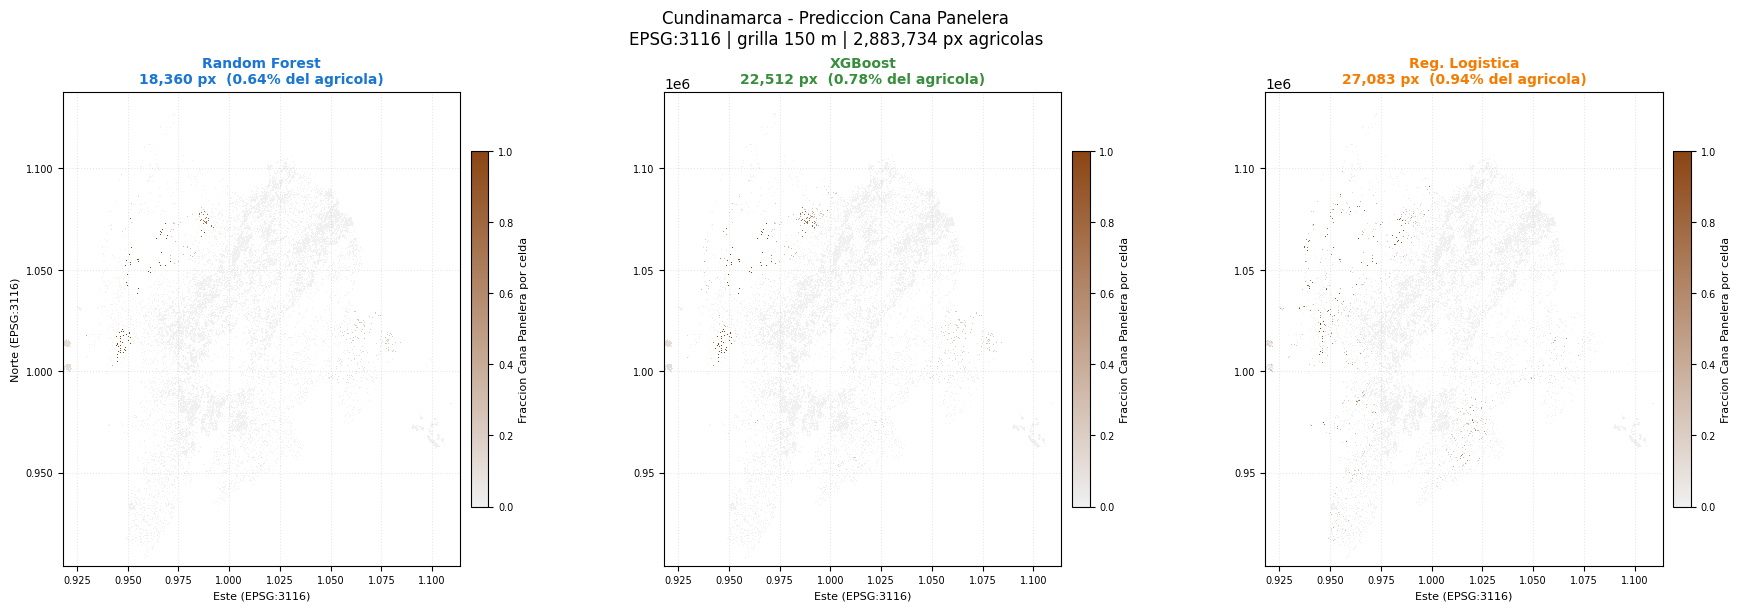

  Cana Panelera: 2.9s -> mapa_cundinamarca_cana_panelera.png


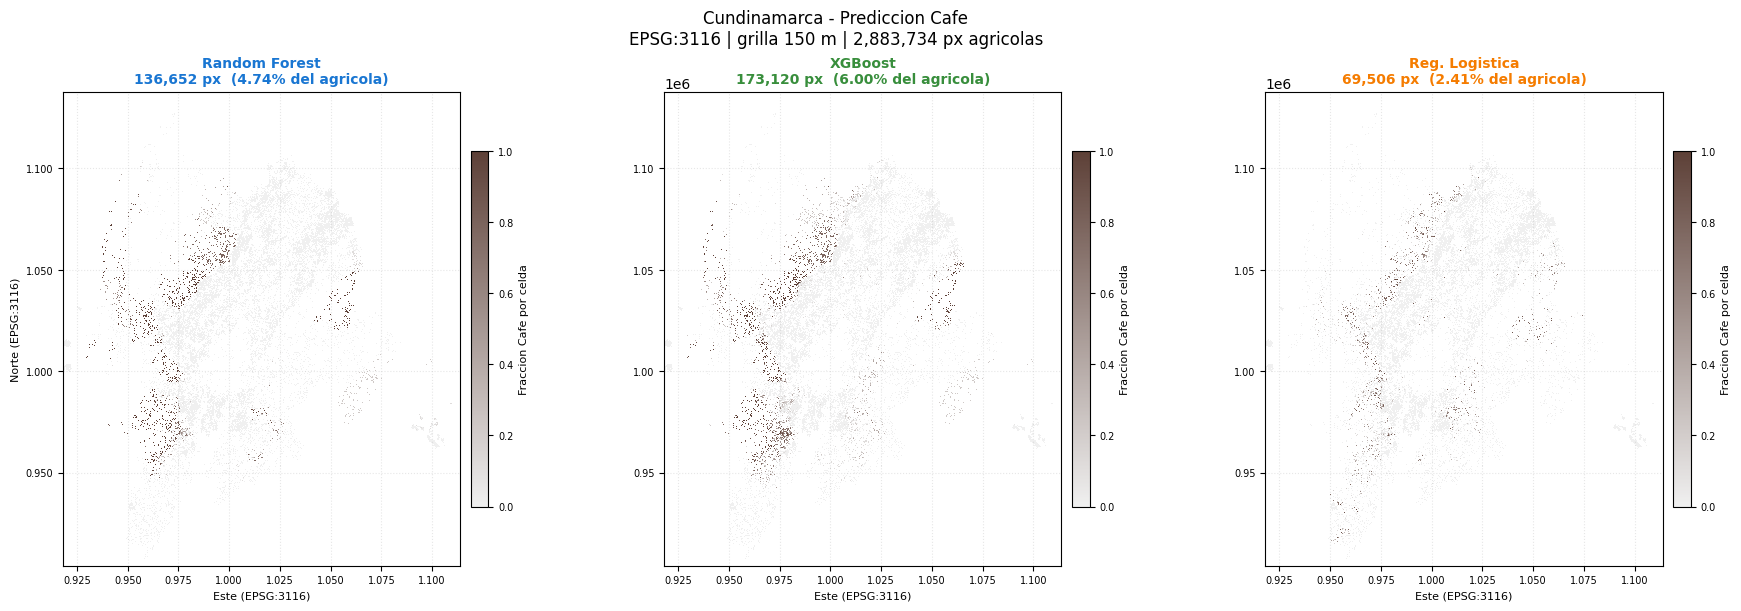

  Cafe: 2.5s -> mapa_cundinamarca_cafe.png


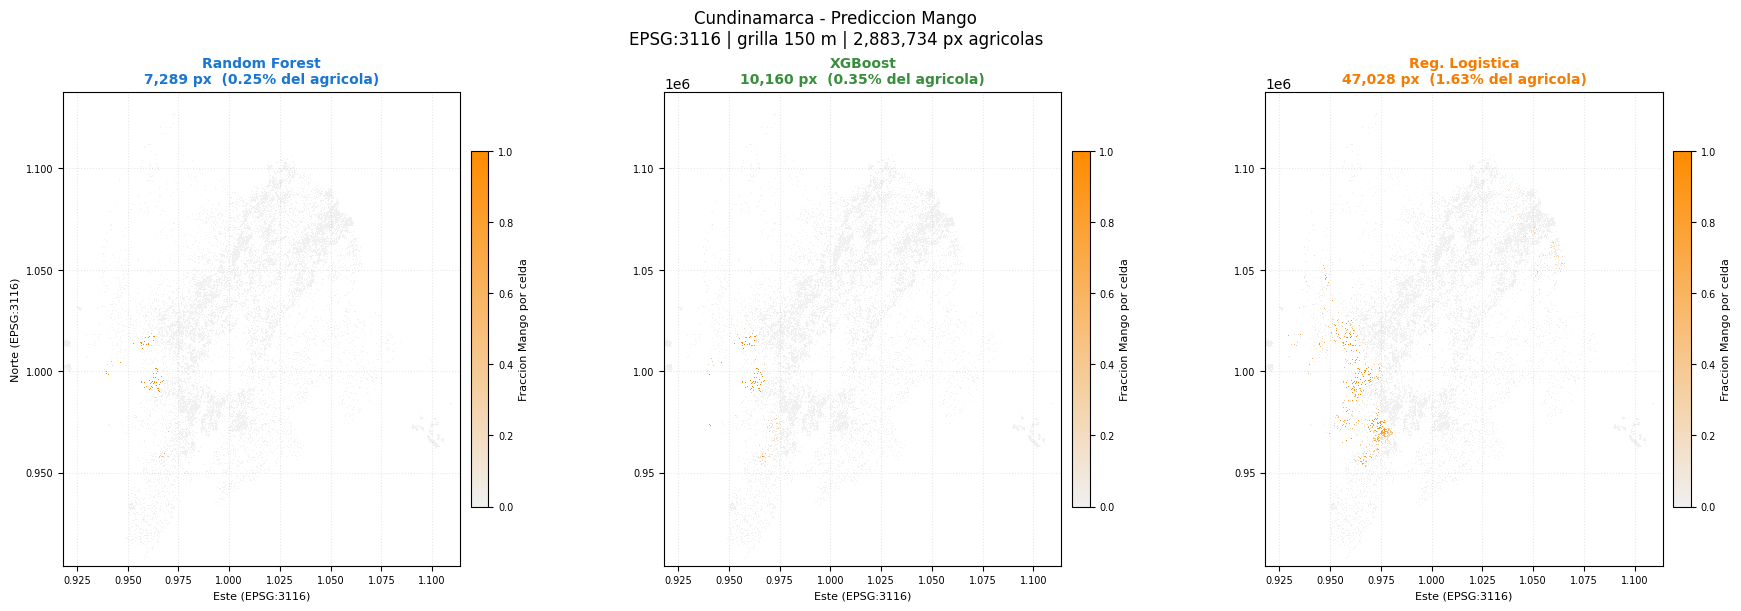

  Mango: 2.5s -> mapa_cundinamarca_mango.png


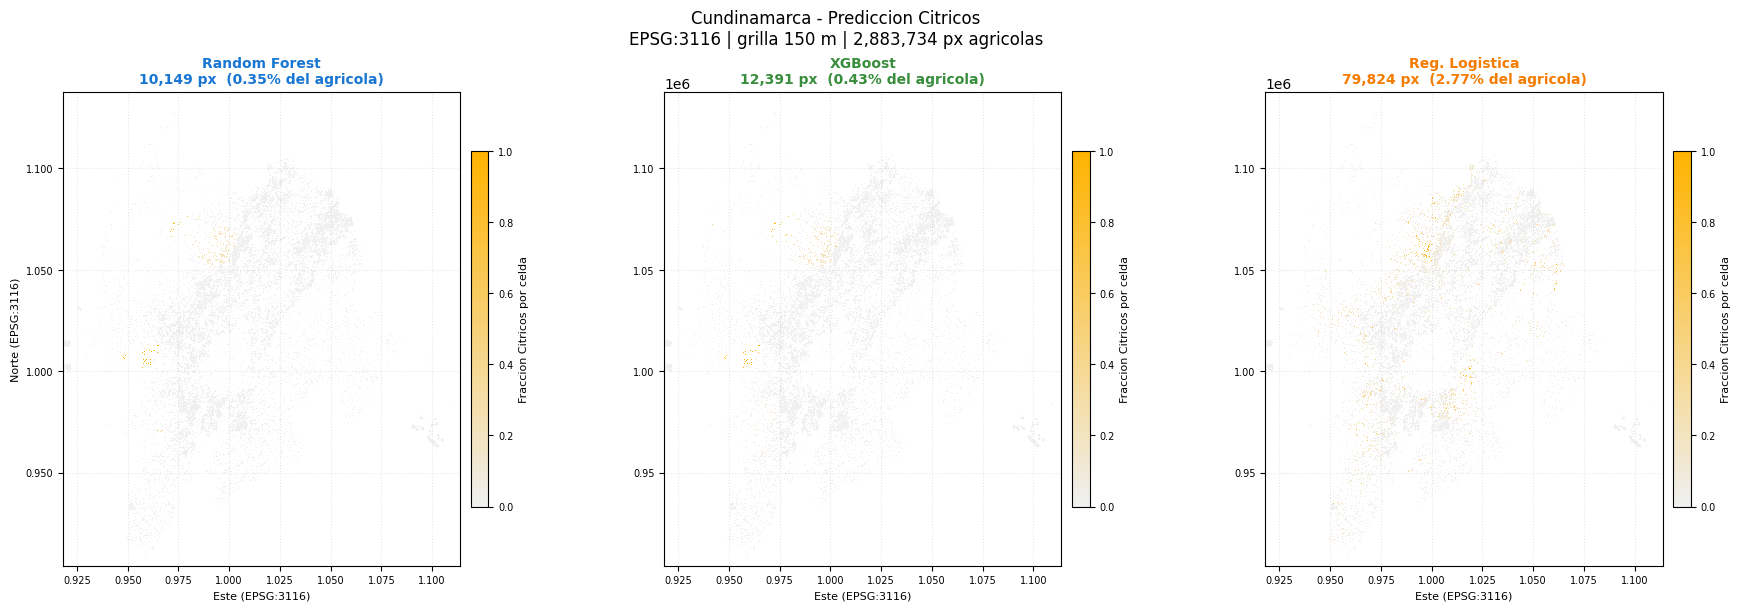

  Citricos: 2.5s -> mapa_cundinamarca_citricos.png


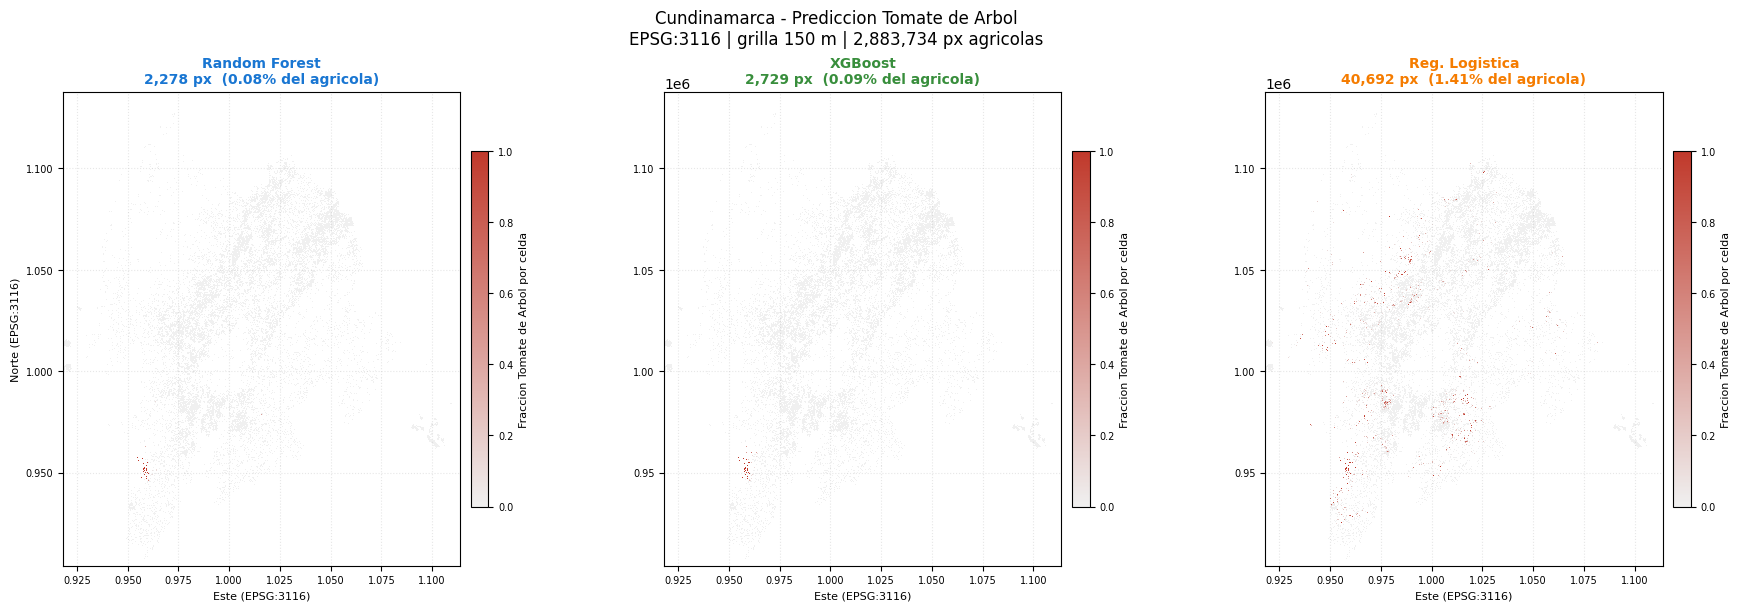

  Tomate de Arbol: 2.5s -> mapa_cundinamarca_tomate_arbol.png

Mapas por cultivo completados.


In [93]:
# ============================================================
# SECCION 10 - Mapas departamentales por cultivo (5 cultivos)
# Reusa: pred_rf, pred_xgb, pred_lr, agr_idx, gx, gy, ny, nx, RES, extent
#        raster_mean_por_celda, modelos_pred (de Seccion 8)
# ============================================================
from matplotlib.colors import LinearSegmentedColormap

# Cultivos a graficar (clase_id, etiqueta, color base de su cmap)
CROPS_EXTRA = [
    ('Cana_Panelera', 'Cana Panelera',   '#8B4513'),   # marron
    ('Cafe',          'Cafe',             '#5D4037'),   # cafe oscuro
    ('Mango',         'Mango',            '#FF8C00'),   # naranja oscuro
    ('Citricos',      'Citricos',         '#FFB300'),   # amarillo dorado
    ('Tomate_Arbol',  'Tomate de Arbol',  '#C0392B'),   # rojo oscuro
]

# Tabla resumen: pixeles predichos por cultivo y modelo (sobre agricolas)
print('Pixeles predichos por cultivo (sobre area agricola):')
print()
print(f'  {"Cultivo":<18} {"RF":>12} {"XGB":>12} {"LR":>12}')
print('  ' + '-' * 60)
for cls_id, label, _ in CROPS_EXTRA:
    ci = CLASES_L2.index(cls_id)
    n_rf  = int((pred_rf  == ci).sum())
    n_xgb = int((pred_xgb == ci).sum())
    n_lr  = int((pred_lr  == ci).sum())
    print(f'  {label:<18} {n_rf:>12,} {n_xgb:>12,} {n_lr:>12,}')

print()
print('Renderizando mapas por cultivo...')

for cls_id, label, base_color in CROPS_EXTRA:
    ci = CLASES_L2.index(cls_id)
    t0 = time.time()

    # Cmap del cultivo: gris muy claro -> color base saturado
    cmap_crop = LinearSegmentedColormap.from_list(
        f'cmap_{cls_id}', ['#f0f0f0', base_color]
    )
    cmap_crop.set_bad('#ffffff', alpha=0.0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    fig.suptitle(
        f'Cundinamarca - Prediccion {label}\n'
        f'EPSG:3116 | grilla {RES:.0f} m | {n_agr:,} px agricolas',
        fontsize=12
    )

    for ax, (nombre, pred_idx, color_modelo) in zip(axes, modelos_pred):
        # Fraccion de pixeles muestreados predichos como ese cultivo por celda
        pred_crop_bin = (pred_idx == ci).astype(np.float32)
        n_pred = int(pred_crop_bin.sum())
        pct    = 100 * n_pred / n_agr if n_agr > 0 else 0.0

        raster_crop = raster_mean_por_celda(
            ny, nx, gy[agr_idx], gx[agr_idx], pred_crop_bin
        )

        im = ax.imshow(raster_crop, origin='lower', extent=extent,
                       cmap=cmap_crop, vmin=0, vmax=1, interpolation='nearest')
        cb = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
        cb.set_label(f'Fraccion {label} por celda', fontsize=8)
        cb.ax.tick_params(labelsize=7)

        ax.set_title(
            f'{nombre}\n{n_pred:,} px  ({pct:.2f}% del agricola)',
            fontsize=10, color=color_modelo, fontweight='bold'
        )
        ax.set_aspect('equal')
        ax.set_xlabel('Este (EPSG:3116)', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.3f}'))
        ax.grid(True, alpha=0.3, linestyle=':')

    axes[0].set_ylabel('Norte (EPSG:3116)', fontsize=8)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y/1e6:.3f}'))

    fname = f'mapa_cundinamarca_{cls_id.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  {label}: {time.time()-t0:.1f}s -> {fname}')

print()
print('Mapas por cultivo completados.')
